# 08 - Streaming Clustering with Drift Monitoring

**Problem framing.** Operational data arrives as a stream, and its distribution can change over time (concept drift). A model trained once and left alone silently degrades. Here we maintain clusters incrementally with mini-batch KMeans and monitor two drift signals per batch: how far the centroids move, and the Population Stability Index (PSI) of a monitored feature against a reference window.

**Assumptions.** Data is consumed in arrival order, batches are large enough to estimate a distribution, and the first batch is a reasonable reference for 'normal'. PSI bands used: ``< 0.1`` stable, ``0.1-0.25`` moderate, ``> 0.25`` major shift.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.streaming import (
    detect_drift_points,
    monitor_streaming_clusters,
)

## A stream with injected drift

The first 1,200 events come from three stable clusters. After that, a fourth regime appears and the monitored feature shifts - a deliberate, known drift so we can check the monitor catches it.

In [2]:
rng = np.random.default_rng(42)
stable = np.vstack(
    [rng.normal(loc=c, scale=0.5, size=(400, 2)) for c in ([0.0, 0.0], [6.0, 6.0], [0.0, 6.0])]
)
drifted = rng.normal(loc=[12.0, 0.0], scale=0.6, size=(800, 2))
stream = np.vstack([stable, drifted])
print(f"stream shape: {stream.shape}; drift injected at row 1200")

stream shape: (2000, 2); drift injected at row 1200


## Monitor the stream

In [3]:
report = monitor_streaming_clusters(
    stream, n_clusters=4, batch_size=200, drift_column=0, random_state=0
)
report.round(3)

,batch,n_seen,centroid_shift,inertia,psi
0,0,200,NaN,35.910,NaN
1,1,400,0.060,38.578,0.032
2,2,600,1.603,841.062,12.434
3,3,800,0.206,336.215,12.434
4,4,1000,0.778,3221.714,0.126
5,5,1200,0.320,1833.536,0.050
6,6,1400,0.552,14725.224,12.434
7,7,1600,0.355,10225.574,12.434
8,8,1800,0.254,7554.318,12.434
9,9,2000,0.188,5687.996,12.434


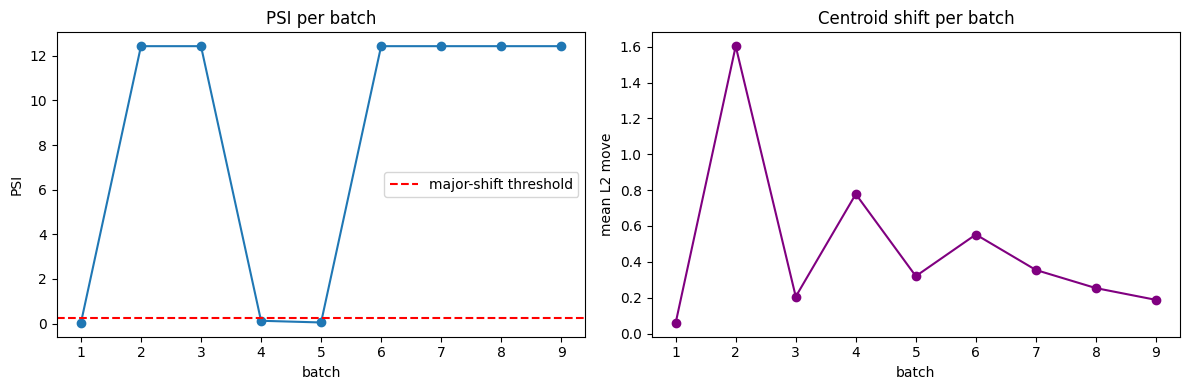

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(report["batch"], report["psi"], marker="o")
ax1.axhline(0.25, color="red", linestyle="--", label="major-shift threshold")
ax1.set_title("PSI per batch")
ax1.set_xlabel("batch")
ax1.set_ylabel("PSI")
ax1.legend()
ax2.plot(report["batch"], report["centroid_shift"], marker="o", color="purple")
ax2.set_title("Centroid shift per batch")
ax2.set_xlabel("batch")
ax2.set_ylabel("mean L2 move")
plt.tight_layout()
plt.show()

In [5]:
drift_batches = detect_drift_points(report["psi"], threshold=0.25)
print(f"batches flagged as drifted: {drift_batches}")
print(f"row 1200 falls in batch {1200 // 200}")

batches flagged as drifted: [2, 3, 6, 7, 8, 9]
row 1200 falls in batch 6


## Baseline comparison

How much do we lose by clustering incrementally instead of in one pass? We compare the streaming model's final assignments against a full-batch KMeans fitted on all the data at once, using Adjusted Mutual Information.

In [6]:
streaming_model = MiniBatchKMeans(n_clusters=4, random_state=0, n_init=3, batch_size=200)
for start in range(0, len(stream), 200):
    streaming_model.partial_fit(stream[start : start + 200])
streaming_labels = streaming_model.predict(stream)

batch_labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(stream)
ami = adjusted_mutual_info_score(streaming_labels, batch_labels)
print(f"AMI(streaming, full-batch) = {ami:.3f}")

AMI(streaming, full-batch) = 0.742


## Interpretation

PSI and centroid shift both spike once the new regime arrives, and `detect_drift_points` flags the corresponding batches. The streaming model tracks the change in a single pass and stays close to the full-batch solution (high AMI), at a fraction of the memory.

## Limitations

- A fixed cluster count cannot represent a genuinely *new* regime; detected drift should trigger a re-fit or a cluster-count review, which this monitor signals but does not perform automatically.
- PSI is univariate here; multivariate drift in correlations can be missed. Monitor several features, or a model-based score, in practice.
- The first batch is assumed representative of 'normal'; a biased reference window produces misleading PSI.